# Testing on the NLST external dataset

In [5]:
%matplotlib inline

### Start

In [6]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:64'


In [56]:

from comet_ml import Experiment
# from fastai.callback.comet import CometCallback

from fastai.vision.all import *
from fastai.basics import *
from fastai.callback.all import *
from fastai.medical.imaging import *
from fastai.data.transforms import IndexSplitter
from fastai.data.core import DataLoaders
from fastai.vision.data import PILImage   
from fastai.learner import Learner
from fastai.losses import BCEWithLogitsLossFlat
import torch
import torch.nn.functional as F

#..... Transforms........
from fastai.vision.augment import RandTransform
from fastai.vision.core import TensorImage
from torchvision.transforms.functional import rotate as tv_rotate
from torchvision.transforms.functional import affine as tv_affine
#from fastai.vision.augment import brightness
from torchvision.transforms.functional import adjust_brightness
from torchvision.transforms.functional import adjust_contrast
import random

import math
import timm

from PIL import Image 
import pydicom

from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import requests
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

#from sklearn.metrics import confusion_matrix, classification_report

In [8]:
### Securing space on the GPU (though not necessary)

if torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("GPU no disponible, usando CPU.") 


GPU disponible: NVIDIA GeForce RTX 3060


In [9]:
from fastai.vision.all import *
defaults.device = device
device

device(type='cuda', index=0)

### Reading data

In [18]:
# Path where the folders containing the grouped Trian image folders are located
# Path donde se localizan las capretas que tienen agrupadas las carpetas de imágenes de trian
source = Path('/home..../lung_cancer_dataset')
data_dir = source 

# Path to the folders containing the NLST images (normalized and converted to JPG so the pre-trained model can recognize them) for this testing.
# Path donde están las capretas de las imágenes de NLST (normalizadas e igualmente convertidas a jpg para que el modelo ya entrenado pueda reconocerlas) este testeo.
test_files = Path('/home.../NLST_CENTRAL')
test_root =  test_files

'''
the suffix _CC: images within the folder with this suffix, meaning "with cancer"

the suffix _NOC: images within the folder with this suffix, meaning "no cancer"
'''


### Defining the transformations to apply data augmentation

In [11]:

#....................    GAUSSIAN NOISE   ..........................#

class AddGaussianNoise(RandTransform):
    "Agregando ruido gaussiano a la imagen con cierta probabilidad"
    '''
    OjO haciéndolo si establecer un rango, la primera vez lo hice con un solo valor y ahora también 
    
    '''
    def __init__(self, std: float=10.0, p: float=0.5):  
        super().__init__(p=p)
        self.std = std
        self.applied = False

    def before_call(self, b, split_idx):
        self.applied = random.random() < self.p

    def encodes(self, img: TensorImage):
        if not self.applied:
            return img
        
        img = img.float() # Convertir a float para evitar errores con Byte
        noise = torch.randn_like(img) * self.std
        noisy_img = img + noise
        return noisy_img.clamp(0, 255)  # Clampea para evitar overflow si es 8-bit


#....................   TRANSLATION   ........................#

class AddTranslation(RandTransform):
    "Aplicando traslación aleatoria dentro del rango [-max_shift, max_shift]"
    '''
     Tamaño imagen: alto=512px, ancho=512px
     Máximo desplazamiento: ±77px
     Desplazamiento máximo en %: ±15.0% vertical, ±15.0% horizontal
    '''
    def __init__(self, max_shift: int = 77, p: float = 0.75):   # 77
        super().__init__(p=p)
        self.max_shift = max_shift
        self.shift_x = 0
        self.shift_y = 0
        self.applied = False  # Inicialmente no aplicada

    def before_call(self, b, split_idx):
        self.applied = random.random() < self.p
        if self.applied:
            self.shift_x = random.randint(-self.max_shift, self.max_shift)
            self.shift_y = random.randint(-self.max_shift, self.max_shift)

        else:
            self.shift_x = 0
            self.shift_y = 0

    def encodes(self, img: TensorImage):
        if not self.applied:
            return img
        img = img.float()
        return tv_affine(img, angle=0.0, translate=[self.shift_x, self.shift_y], scale=1.0, shear=[0.0, 0.0])



In [12]:
#....................    ROTATE   ............................#

class MyRandomRotate(RandTransform):
    
    def __init__(self, max_deg=10, p=0.75):  
        super().__init__(p=p)
        self.max_deg = max_deg
        self.last_angle = None  

    def before_call(self, b, split_idx):
        self.last_angle = random.uniform(-self.max_deg, self.max_deg)

    def encodes(self, x: TensorImage):
        return tv_rotate(x, self.last_angle)
        

#....................    ZOOM   ..........................#

class MyRandomZoom(RandTransform):
   
    def __init__(self, min_zoom=0.9, max_zoom=1.10, p=0.75):
        super().__init__(p=p)
        self.min_zoom = min_zoom
        self.max_zoom = max_zoom
        self.last_zoom = None

    def before_call(self, b, split_idx):
        self.last_zoom = random.uniform(self.min_zoom, self.max_zoom)
        super().before_call(b, split_idx)

    def encodes(self, x: TensorImage):
        if x.ndim == 3:
            # Una sola imagen: (C, H, W)
            _, h, w = x.shape
        elif x.ndim == 4:
            # Lote de imágenes: (B, C, H, W)
            _, _, h, w = x.shape
        else:
            raise ValueError(f"Unexpected shape: {x.shape}")

    # Inverse of zoom is scale in affine: 1.0 / zoom
        scale = self.last_zoom
        return tv_affine(x, angle=0.0, translate=[0, 0], scale=scale, shear=[0.0, 0.0])


#....................   FLIP HORIZONTAL   ...............................#

class MyRandomFlip(RandTransform):
    
    def __init__(self, p=0.75):
        super().__init__(p=p)
        self.flipped_h = None

    def before_call(self, b, split_idx):
        self.flipped_h = random.random() < self.p

    def encodes(self, x: TensorImage):
        if self.flipped_h:
            return torch.flip(x, dims=[2])  
        return x

#....................    FLIP VERTICAL   .............................#

class MyRandomFlipVert(RandTransform):
    
    def __init__(self, p=0.75):
        super().__init__(p=p)
        self.flipped_v = None

    def before_call(self, b, split_idx):
        self.flipped_v = random.random() < self.p

    def encodes(self, x: TensorImage):
        if self.flipped_v:
            return torch.flip(x, dims=[1])  
        return x
        

#....................  ILUMINACIÓN (BRIGHTNESS Y CONTRASTE)    ........................#

class MyRandomLighting(RandTransform):
    
    def __init__(self, max_lighting=0.2, p=0.75):
        super().__init__(p=p)
        self.max_lighting = max_lighting
        self.last_brightness = 1.0
        self.applied = False

    def before_call(self, b, split_idx):
        self.applied = random.random() < self.p
        
        if self.applied:
            '''
            debe hacer así 
            -0.5 * (1 - max_lighting)   y   +0.5 * (1 + max_lighting)
            y luego  convertirlo a un factor válido sumando 1
            '''
            min_val = -0.5 * (1 - self.max_lighting)
            max_val = +0.5 * (1 + self.max_lighting)
            brightness_change = random.uniform(min_val, max_val)
            self.last_brightness = 1 + brightness_change
        else:
            self.last_brightness = 1.0
    
    def encodes(self, x: TensorImage):
        if self.applied:
            return adjust_brightness(x, brightness_factor=self.last_brightness)
        return x


class MyRandomContrast(RandTransform):
    def __init__(self, max_contrast=0.2, p=0.75):
        super().__init__(p=p)
        self.max_contrast = max_contrast
        self.last_contrast = 1.0
        self.applied = False

    def before_call(self, b, split_idx):
        self.applied = random.random() < self.p
        
        if self.applied:
            low = 1 - self.max_contrast
            high = 1 / (1 - self.max_contrast)
            log_low = math.log(low)
            log_high = math.log(high)
            self.last_contrast = math.exp(random.uniform(log_low, log_high))
        else:
            self.last_contrast = 1.0
    
    def encodes(self, x: TensorImage):
        if self.applied:
            return adjust_contrast(x, contrast_factor=self.last_contrast)
        return x


### Applying transforms and loading data

In [13]:

my_transforms = [
    Normalize.from_stats(*imagenet_stats),  # *imagenet_stats # 
]

In [14]:

dls = ImageDataLoaders.from_folder(
    data_dir,
    #get_items=get_i,
    valid_pct=0.2,  
    item_tfms=Resize(512, method='pad',pad_mode='zeros' ), # https://docs.fast.ai/vision.augment.html#resize                 
    batch_tfms=my_transforms,  
    seed=42,  
    bs=8, 
    drop_last=False,   # so that it does not delete the final batch that lacks a full set of images
    num_workers=0,
)

In [15]:
print(dls.vocab)

['Bengin', 'Malignant', 'Normal']


### Model loading and learner creation

In [19]:

learn = vision_learner(
    dls,
    'efficientnet_b1', 
    pretrained= True,
    loss_func=CrossEntropyLossFlat(),
    metrics=[accuracy, Precision(average='macro'), Recall(average='macro'), F1Score(average='macro')],
    model_dir='_Ef_',
).to_fp16()

learn.load('E-1500')

/home2/rosmeri/myenv/lib/python3.11/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_l

In [20]:
print(learn.dls.vocab)

['Bengin', 'Malignant', 'Normal']


### Testing

In [21]:

valid_exts = {'.png', '.jpg', '.jpeg'}

#  Build a list of files and binary labels. 
def gather_from_nested(root: Path):
    files, y = [], []
    for cls_name, label in [("NOC", 0), ("CC", 1)]:
        for patient_dir in (root / cls_name).iterdir():
            if not patient_dir.is_dir():
                continue
            for img in patient_dir.glob("*.jpg"):
                files.append(img)
                y.append(label)
    return files, torch.tensor(y)

test_files, y_true = gather_from_nested(test_root)
print("N test:", len(test_files), " N CC:", int((y_true==1).sum()), " N NOC:", int((y_true==0).sum()))

# Create test DataLoader
test_dl = learn.dls.test_dl(test_files, with_labels=False)  

# Obtain predictions from the original model (3 clases) 
logits, _ = learn.get_preds(dl=test_dl)       # logits: (N,3)
probs = torch.softmax(logits, dim=1)          # probs (N,3)

print(probs)

pred_3_clases = torch.argmax(probs, dim=1)
print(pred_3_clases)


y_pred = (pred_3_clases == 1).long()
y_true_nocc = (y_true !=1).long()

print(y_true_nocc)


score_CC = probs[:, 1]  
#score_noCC = probs[:, 0]+ probs[:, 2]
score_noCC = np.maximum(probs[:, 0], probs[:, 2])


print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["NOC","CC"]))



N test: 3599  N CC: 1655  N NOC: 1944


/home2/rosmeri/myenv/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/home2/rosmeri/myenv/lib/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


tensor([[0.2132, 0.2148, 0.5720],
        [0.2202, 0.2358, 0.5440],
        [0.2156, 0.2202, 0.5642],
        ...,
        [0.2289, 0.4943, 0.2769],
        [0.2365, 0.3757, 0.3878],
        [0.2188, 0.5613, 0.2199]])
tensor([2, 2, 2,  ..., 1, 2, 1])
tensor([1, 1, 1,  ..., 0, 0, 0])

Classification Report:
              precision    recall  f1-score   support

         NOC       0.82      0.92      0.87      1944
          CC       0.89      0.76      0.82      1655

    accuracy                           0.85      3599
   macro avg       0.85      0.84      0.84      3599
weighted avg       0.85      0.85      0.84      3599



In [22]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)
for cls, p, r, f, s in zip(['NOC','CC'], precision, recall, f1, support):
    print(f"{cls}: precision={p*100:.2f}%, recall={r*100:.2f}%, f1={f*100:.2f}%, n={s}")

NOC: precision=81.85%, recall=91.87%, f1=86.57%, n=1944
CC: precision=88.85%, recall=76.07%, f1=81.97%, n=1655


In [23]:
probs[:, 0]


tensor([0.2132, 0.2202, 0.2156,  ..., 0.2289, 0.2365, 0.2188])

In [24]:
probs[:, 1]

tensor([0.2148, 0.2358, 0.2202,  ..., 0.4943, 0.3757, 0.5613])

In [25]:
probs[:, 2]

tensor([0.5720, 0.5440, 0.5642,  ..., 0.2769, 0.3878, 0.2199])

In [26]:
print(y_true)
print(y_true_nocc)

tensor([0, 0, 0,  ..., 1, 1, 1])
tensor([1, 1, 1,  ..., 0, 0, 0])


In [27]:
y_true

tensor([0, 0, 0,  ..., 1, 1, 1])

In [28]:
print(y_true.sum(), len(y_true))

tensor(1655) 3599


In [30]:
from sklearn.metrics import roc_auc_score, roc_curve

y_true_binary = y_true.numpy()  # 1 = CC (cáncer), 0 = NOC 
score_CC = probs[:, 1].numpy()  

auc_score = roc_auc_score(y_true_binary, score_CC)
fpr, tpr, thresholds = roc_curve(y_true_binary, score_CC)
print(f"AUC (Malignant's continuous score): {auc_score:.4f}")

AUC (score continuo de Maligno): 0.8915


### Predictions

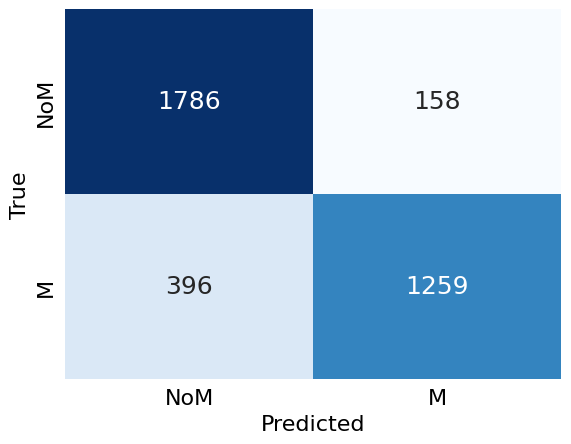

In [31]:

cm = confusion_matrix(y_true, y_pred)

abbreviations = ['NoM', 'M']  #

sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cbar=False,
            cmap='Blues', 
            xticklabels=['NoM', 'M'], 
            yticklabels=['NoM', 'M'],
            annot_kws={"size": 18})  


plt.xticks(fontsize=16)  # size on the x-axis
plt.yticks(fontsize=16)  # size on the y-axis


plt.xlabel('Predicted', fontsize=16)
plt.ylabel('True', fontsize=16)
plt.tick_params(left=False, bottom=False, labelleft=True, labelbottom=True)

plt.savefig('Figure_.png', dpi=300, bbox_inches='tight')
plt.show()


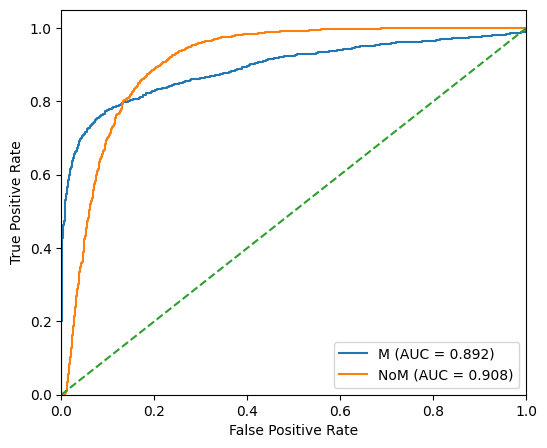

In [32]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_true_np = y_true ==1
# ROC for CC (positive = 1)
fpr_cc, tpr_cc, _ = roc_curve(y_true_np, score_CC)
auc_cc = auc(fpr_cc, tpr_cc)

# ROC for non-CC
fpr_nocc, tpr_nocc, _ = roc_curve(y_true_nocc, score_noCC)
auc_nocc = auc(fpr_nocc, tpr_nocc)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr_cc, tpr_cc, label=f'M (AUC = {auc_cc:.3f})')
plt.plot(fpr_nocc, tpr_nocc, label=f'NoM (AUC = {auc_nocc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()



In [25]:
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [33]:
# check image size
patient_dir = "/home.../NLST_CENTRAL/CC/100147"

images = sorted([f for f in os.listdir(patient_dir) if f.endswith(".jpg")])

for img_name in images:
    img = Image.open(os.path.join(patient_dir, img_name))
    print(img_name, img.size, img.mode)


100147_1-091.jpg (512, 512) RGB
100147_1-092.jpg (512, 512) RGB
100147_1-093.jpg (512, 512) RGB


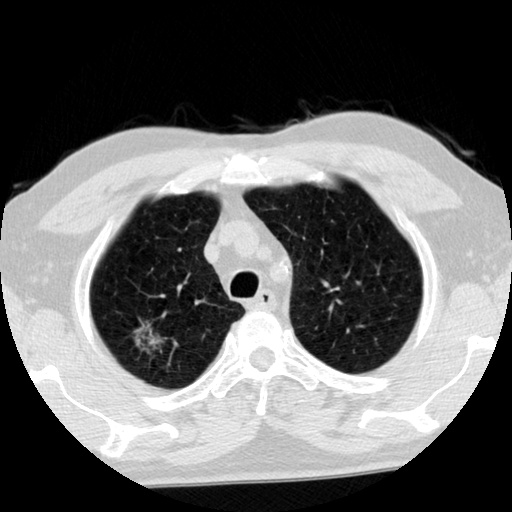

In [34]:
img = Image.open(os.path.join(patient_dir, images[1]))
arr = np.array(img)
img

### Per patient 

In [37]:
from collections import defaultdict

# Associate image with patient
def get_patient_id(path):
    return path.parent.name  

# Create dictionaries: {patient: [predictions]} and {patient: [true labels]}
preds_by_patient = defaultdict(list)
probs_by_patient = defaultdict(list)
true_by_patient = defaultdict(list)


for path, pred, true in zip(test_files, y_pred, y_true):
    pid = get_patient_id(path)
    preds_by_patient[pid].append(pred.item())
    true_by_patient[pid].append(true.item())


In [40]:

def has_consecutive_preds(pred_list, min_consecutive=3):
    count = 0
    for p in pred_list:
        if p == 1:  # positive prediction
            count += 1
            if count >= min_consecutive:
                return True
        else:
            count = 0
    return False

def has_min_prob_preds(prob_list, threshold=0.5, min_hits=3):
    hits = sum(p > threshold for p in prob_list)
    return hits >= min_hits

# Triage patients
y_patient_pred = []
y_patient_true = []

for pid in preds_by_patient:
    preds = preds_by_patient[pid]
    is_cancer = has_consecutive_preds(preds, min_consecutive=3)

    y_patient_pred.append(1 if is_cancer else 0)

    # Actual value
    true_label = round(sum(true_by_patient[pid]) / len(true_by_patient[pid]))
    y_patient_true.append(true_label)


In [41]:

print(confusion_matrix(y_patient_true, y_patient_pred))
print(classification_report(y_patient_true, y_patient_pred, target_names=["NOC", "CC"]))

[[634  14]
 [169 384]]
              precision    recall  f1-score   support

         NOC       0.79      0.98      0.87       648
          CC       0.96      0.69      0.81       553

    accuracy                           0.85      1201
   macro avg       0.88      0.84      0.84      1201
weighted avg       0.87      0.85      0.84      1201



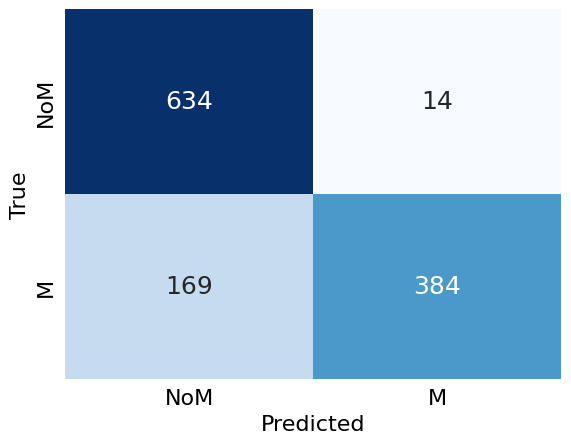

In [42]:

abbreviations = ['NoM', 'M']  
cm2 = confusion_matrix(y_patient_true, y_patient_pred) 
cm_percent = cm2 / cm2.sum() * 100  
sns.heatmap(cm2, 
            annot=True, 
            fmt='d', 
            cbar=False,
            cmap='Blues', 
            xticklabels=['NoM', 'M'], 
            yticklabels=['NoM', 'M'],
            annot_kws={"size": 18})  

plt.xticks(fontsize=16)  
plt.yticks(fontsize=16) 

plt.xlabel('Predicted', fontsize=16)
plt.ylabel('True', fontsize=16)
plt.tick_params(left=False, bottom=False, labelleft=True, labelbottom=True)

#plt.savefig('Figure_.png', dpi=300, bbox_inches='tight')
plt.show()

#### Analyzing DICOM variation by patient

In [48]:
# patient CC
NLST_DICOMS_INFO = Path("/home.../nlst/NLST_cc/")

# patient NCC
NLST_DICOMS_INFO_noc = Path("/home.../nlst/NLST_noc/")
                               

In [57]:

def extract_scanner_info(dicom_root):
    """
    Iterate through the patient folders, enter each series, read a *single* 
    DICOM file per patient (the first one suffices; the scanner settings do not 
    change between slices of the same series), 
    and extract the relevant fields.
    """
    records = []
    for patient_dir in Path(dicom_root).iterdir():
        if not patient_dir.is_dir():
            continue
        dicom_files = list(patient_dir.rglob('*.dcm'))
        if not dicom_files:
            continue
        try:
            ds = pydicom.dcmread(dicom_files[0], stop_before_pixels=True)
            records.append({
                'patient_id': patient_dir.name,
                'manufacturer': getattr(ds, 'Manufacturer', None),
                'model': getattr(ds, 'ManufacturerModelName', None),
                'kvp': getattr(ds, 'KVP', None),
                'slice_thickness': getattr(ds, 'SliceThickness', None),
                'study_description': getattr(ds, 'StudyDescription', None),
            })
        except Exception as e:
            records.append({'patient_id': patient_dir.name, 'manufacturer': None, 'error': str(e)})
    return pd.DataFrame(records)



In [58]:
df_cc = extract_scanner_info(NLST_DICOMS_INFO)
df_noc = extract_scanner_info(NLST_DICOMS_INFO_noc)
scanner_df = pd.concat([df_cc, df_noc], ignore_index=True)
scanner_df.to_csv('scanner_info_by_patient.csv', index=False)
print(scanner_df['manufacturer'].value_counts())

manufacturer
GE MEDICAL SYSTEMS    646
SIEMENS               432
Philips                97
TOSHIBA                88
Name: count, dtype: int64


In [59]:
df_cc

,patient_id,manufacturer,model,kvp,slice_thickness,study_description
0,123629,GE MEDICAL SYSTEMS,LightSpeed16,140.0,2.50,NLST-LSS
1,131486,GE MEDICAL SYSTEMS,LightSpeed16,140.0,2.50,NLST-LSS
2,115954,GE MEDICAL SYSTEMS,LightSpeed QX/i,120.0,2.50,NLST-LSS
3,210839,GE MEDICAL SYSTEMS,LightSpeed Pro 16,120.0,1.25,NLST-ACRIN
4,110817,SIEMENS,Sensation 16,120.0,2.00,NLST-LSS
...,...,...,...,...,...,...
610,208589,SIEMENS,Sensation 64,120.0,2.00,NLST-ACRIN
611,116289,GE MEDICAL SYSTEMS,LightSpeed QX/i,120.0,2.50,NLST-LSS
612,217482,GE MEDICAL SYSTEMS,LightSpeed16,120.0,2.50,NLST-ACRIN
613,105540,Philips,Mx8000,120.0,3.20,NLST-LSS


In [60]:
image_level_records = []
for path, pred, true in zip(test_files, y_pred, y_true):
    pid = get_patient_id(path)
    image_level_records.append({'patient_id': pid, 'pred': pred.item(), 'true': true.item(),
                                  'correct': int(pred.item() == true.item())})

results_df = pd.DataFrame(image_level_records)
merged = results_df.merge(scanner_df[['patient_id', 'manufacturer']], on='patient_id', how='left')

print(f"Images with no manufacturer found: {merged['manufacturer'].isna().sum()}")
print(merged.groupby('manufacturer')['correct'].agg(['mean', 'count']))

Imágenes sin manufacturer encontrado: 0
                        mean  count
manufacturer                       
GE MEDICAL SYSTEMS  0.885621   1836
Philips             0.900344    291
SIEMENS             0.779521   1211
TOSHIBA             0.816092    261


In [61]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(merged['manufacturer'], merged['correct'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"Chi-cuadrado: {chi2:.2f}, p-valor: {p_value:.6f}")
print(contingency)

Chi-cuadrado: 71.62, p-valor: 0.000000
correct               0     1
manufacturer                 
GE MEDICAL SYSTEMS  210  1626
Philips              29   262
SIEMENS             267   944
TOSHIBA              48   213


In [62]:
# One manufacturer per patient (we take the first one, since all images
# from the same patient share the same scanner)
manufacturer_by_patient = scanner_df.set_index('patient_id')['manufacturer'].to_dict()

# Reconstruct the table at the patient level, with their confounding category
patient_records = []
for pid, pred, true in zip(preds_by_patient.keys(), y_patient_pred, y_patient_true):
    mfr = manufacturer_by_patient.get(pid, 'Unknown')
    if true == 0 and pred == 0:
        category = 'True Negative (NoM)'
    elif true == 0 and pred == 1:
        category = 'False Positive'
    elif true == 1 and pred == 0:
        category = 'False Negative'
    else:
        category = 'True Positive (M)'
    patient_records.append({'patient_id': pid, 'manufacturer': mfr, 'category': category})

patient_df = pd.DataFrame(patient_records)

# Crosstab: confusion category x manufacturer
crosstab = pd.crosstab(patient_df['category'], patient_df['manufacturer'])
print(crosstab)

# Version with row percentages (what % of each category comes from each manufacturer)
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
print(crosstab_pct.round(1))

manufacturer         GE MEDICAL SYSTEMS  Philips  SIEMENS  TOSHIBA
category                                                          
False Negative                       65        6       85       13
False Positive                        3        1        7        3
True Negative (NoM)                 310       56      227       41
True Positive (M)                   234       34       86       30
manufacturer         GE MEDICAL SYSTEMS  Philips  SIEMENS  TOSHIBA
category                                                          
False Negative                     38.5      3.6     50.3      7.7
False Positive                     21.4      7.1     50.0     21.4
True Negative (NoM)                48.9      8.8     35.8      6.5
True Positive (M)                  60.9      8.9     22.4      7.8
